# Nius
Load Nius CSV files and create a DataFrame named `df`.

In [48]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Nius"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
pd.reset_option('display.max_colwidth')
df.head()


Loaded 4885 rows from 285 file(s) in /Users/gretawette/Documents/Thesis/data/raw/Alternative Medien/Nius


,id,title,titleHtml,intro,articleRef,categoryRef,articleAltRef,images,tags,video,...,isPaidContent,isTopClickModule,topClickCustomContent,showSystemTeaserTitle,meta,url,day,article_text,source,source_file
0,0682defd-0f5f-4469-812b-20d7cca70273,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,<span>Zitter-Wahl oder Durchmarsch: Wie sicher...,NaN,/politik/news/zitter-wahl-oder-durchmarsch-wie...,/politik,/articles/zitter-wahl-oder-durchmarsch-wie-sic...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': ""Zitter-Wahl oder Durchmarsch: Wie s...",https://www.nius.de/politik/news/zitter-wahl-o...,2025-05-01,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,Nius,nius_2025-05-01.csv
1,53d0259d-761e-4377-84b8-12185aaf54e8,"Erst fällt die Brandmauer, dann fließen Tränen...","<span>Erst fällt die Brandmauer, dann fließen ...",NaN,/gesellschaft/news/brandmauer-wurzen-demokrati...,/gesellschaft,/articles/brandmauer-wurzen-demokratie-netzwer...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': 'Erst fällt die Brandmauer, dann fli...",https://www.nius.de/gesellschaft/news/brandmau...,2025-05-01,"# Erst fällt die Brandmauer, dann fließen Trän...",Nius,nius_2025-05-01.csv
2,4535cc72-254b-4fd5-a7b6-24a24de52784,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",<span>Als Merkel noch mal „Wir schaffen das“ s...,NaN,/gesellschaft/news/angela-merkel-evangelischer...,/gesellschaft,/articles/angela-merkel-evangelischer-kirchent...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Als Merkel noch mal „Wir schaffen d...,https://www.nius.de/gesellschaft/news/angela-m...,2025-05-01,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",Nius,nius_2025-05-01.csv
3,3c62c613-6cb8-49da-a8f6-c3727a9e55b6,Absage an Transideologie: Englischer Fußballve...,<span>Absage an Transideologie: Englischer Fuß...,NaN,/sport/news/absage-an-transideologie-englische...,/sport,/articles/absage-an-transideologie-englischer-...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Absage an Transideologie: Englische...,https://www.nius.de/sport/news/absage-an-trans...,2025-05-01,# Absage an Transideologie: Englischer Fußball...,Nius,nius_2025-05-01.csv
4,152af3f3-137d-4a51-8f8c-5bf8c5cdbe8b,Ex-Briten-Premier Tony Blair: Bisherige Klima...,<span>Ex-Briten-Premier Tony Blair: Bisherige...,NaN,/politik/news/ex-briten-premier-tony-blair-bis...,/politik,/articles/ex-briten-premier-tony-blair-bisheri...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Ex-Briten-Premier Tony Blair: Bish...,https://www.nius.de/politik/news/ex-briten-pre...,2025-05-01,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,Nius,nius_2025-05-01.csv


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4885 non-null   object 
 1   title                  4885 non-null   object 
 2   titleHtml              4885 non-null   object 
 3   intro                  3 non-null      object 
 4   articleRef             4885 non-null   object 
 5   categoryRef            4885 non-null   object 
 6   articleAltRef          4885 non-null   object 
 7   images                 4885 non-null   object 
 8   tags                   4885 non-null   object 
 9   video                  0 non-null      float64
 10  categories             4885 non-null   object 
 11  slug                   4885 non-null   object 
 12  lastModified           4885 non-null   object 
 13  created                4885 non-null   object 
 14  publishedAt            4885 non-null   object 
 15  temp

## Data Cleaning

In [50]:
df_clean = df[['title', 'categories', 'day', 'authors', 'article_text', 'url']].copy()
df_clean.head()

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,"[{'id': '644a4264f03076c588c3da92', 'email': '...",# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,"[{'id': '64ac16eb3450f0e44302535e', 'email': '...","# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...","# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,"[{'id': '644a43e2f03076c588c3dad6', 'email': '...",# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         4885 non-null   object
 1   categories    4885 non-null   object
 2   day           4885 non-null   object
 3   authors       4885 non-null   object
 4   article_text  4872 non-null   object
 5   url           4885 non-null   object
dtypes: object(6)
memory usage: 229.1+ KB


In [52]:
nan_counts = df_clean.isna().sum()
total_nans = int(nan_counts.sum())

print(f"Any NaNs in df: {total_nans > 0}")
print(f"Total NaN values: {total_nans}")

Any NaNs in df: True
Total NaN values: 13


In [53]:
# Clean the data by dropping rows with NaN values
df_clean = df_clean.dropna()
print(f"Rows after dropping NaNs: {len(df_clean)}")

Rows after dropping NaNs: 4872


In [54]:
import ast
import re

def extract_author_name(authors_str):
    """Extract author name(s) from the authors column."""
    if pd.isna(authors_str) or authors_str is None:
        return None
    
    # Convert to string if not already
    authors_str = str(authors_str)
    
    # Use regex to extract all 'name': 'value' patterns directly
    matches = re.findall(r"'name':\s*'([^']*)'", authors_str)
    if matches:
        return ', '.join(matches)
    
    # Try double quotes as well
    matches = re.findall(r'"name":\s*"([^"]*)"', authors_str)
    if matches:
        return ', '.join(matches)
    
    return None

# Apply to the dataframe
df_clean['authors'] = df_clean['authors'].apply(extract_author_name)
df_clean.head()
   

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [55]:
pd.set_option('display.max_colwidth', None)
df_clean.head(5)

title  \
0                                                   Zitter-Wahl oder Durchmarsch: Wie sicher ist Friedrich Merz' Kanzlerwahl?   
1  Erst fällt die Brandmauer, dann fließen Tränen: Stadtrat in Wurzen stoppt Finanzierung von örtlichem „Demokratie-Netzwerk“   
2                        Als Merkel noch mal „Wir schaffen das“ sagt, bricht beim Kirchentags-Publikum grenzenloser Jubel aus   
3                           Absage an Transideologie: Englischer Fußballverband schließt ab Juni Männer vom Frauenfußball aus   
4                                            Ex-Briten-Premier Tony Blair:  Bisherige Klimapolitik „zum Scheitern verurteilt“   

         categories         day             authors  \
0       ['Politik']  2025-05-01        Ralf Schuler   
1  ['Gesellschaft']  2025-05-01  Marc Sierzputowski   
2  ['Gesellschaft']  2025-05-01           Redaktion   
3         ['Sport']  2025-05-01           Redaktion   
4       ['Politik']  2025-05-01         Julius Böhm   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [56]:
def remove_trailing_nius_reference(text):
    """Remove trailing 'Mehr NIUS:', 'Auch bei NIUS:', etc. from article text."""
    if pd.isna(text) or text is None:
        return text
    
    # Pattern to match trailing NIUS references at the end of the text
    # Matches variations like "Mehr NIUS:", "Mehr bei NIUS:", "Auch bei NIUS:", etc.
    # followed by any remaining text until the end
    pattern = r'\n*(?:Mehr|Auch|Lesen\s+[Ss]ie\s+auch)\s+(?:bei\s+)?NIUS\s*:.*$'
    
    cleaned = re.sub(pattern, '', str(text), flags=re.IGNORECASE | re.DOTALL)
    return cleaned.strip()

df_clean['article_text'] = df_clean['article_text'].apply(remove_trailing_nius_reference)
df_clean.head(10)

title  \
0                                                          Zitter-Wahl oder Durchmarsch: Wie sicher ist Friedrich Merz' Kanzlerwahl?   
1         Erst fällt die Brandmauer, dann fließen Tränen: Stadtrat in Wurzen stoppt Finanzierung von örtlichem „Demokratie-Netzwerk“   
2                               Als Merkel noch mal „Wir schaffen das“ sagt, bricht beim Kirchentags-Publikum grenzenloser Jubel aus   
3                                  Absage an Transideologie: Englischer Fußballverband schließt ab Juni Männer vom Frauenfußball aus   
4                                                   Ex-Briten-Premier Tony Blair:  Bisherige Klimapolitik „zum Scheitern verurteilt“   
5              „Wir neigen zu fürchterlicher Herablassung“: Historiker Prof. Rödder kritisiert Deutschlands Umgang mit Donald Trump    
6                 US-Außenminister Marco Rubio folgt auf gefeuerten Trump-Berater Waltz, der wiederum US-Botschafter bei der UN wird   
7                                Schüsse und Stiche während 1. Mai-Demo: Zwei Schwerverletzte in Berlin – Polizei fahndet nach Täter   
8                                         Verurteilter IS-Unterstützer aus Syrien verlangt von Deutschland 144.000 Euro für Ausreise   
9  Die linke Kaderschmiede im Innenministerium: Was passiert mit der Bundeszentrale für politische Bildung unter einem CSU-Minister?   

                     categories         day             authors  \
0                   ['Politik']  2025-05-01        Ralf Schuler   
1              ['Gesellschaft']  2025-05-01  Marc Sierzputowski   
2              ['Gesellschaft']  2025-05-01           Redaktion   
3                     ['Sport']  2025-05-01           Redaktion   
4                   ['Politik']  2025-05-01         Julius Böhm   
5  ['Schuler! Fragen, was ist']  2025-05-01        Ralf Schuler   
6                   ['Ausland']  2025-05-01           Redaktion   
7              ['Kriminalität']  2025-05-01           Redaktion   
8              ['Kriminalität']  2025-05-02           Redaktion   
9                   ['Politik']  2025-05-02         Björn Harms   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [57]:
# Remove newline characters from article_text
df_clean['article_text'] = df_clean['article_text'].str.replace('\n', ' ', regex=False)
df_clean.head()

title  \
0                                                   Zitter-Wahl oder Durchmarsch: Wie sicher ist Friedrich Merz' Kanzlerwahl?   
1  Erst fällt die Brandmauer, dann fließen Tränen: Stadtrat in Wurzen stoppt Finanzierung von örtlichem „Demokratie-Netzwerk“   
2                        Als Merkel noch mal „Wir schaffen das“ sagt, bricht beim Kirchentags-Publikum grenzenloser Jubel aus   
3                           Absage an Transideologie: Englischer Fußballverband schließt ab Juni Männer vom Frauenfußball aus   
4                                            Ex-Briten-Premier Tony Blair:  Bisherige Klimapolitik „zum Scheitern verurteilt“   

         categories         day             authors  \
0       ['Politik']  2025-05-01        Ralf Schuler   
1  ['Gesellschaft']  2025-05-01  Marc Sierzputowski   
2  ['Gesellschaft']  2025-05-01           Redaktion   
3         ['Sport']  2025-05-01           Redaktion   
4       ['Politik']  2025-05-01         Julius Böhm   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [58]:
# Extract relevant time period
# Convert 'day' column to datetime 
df_clean['day'] = pd.to_datetime(df_clean['day'])

# Filter for articles from August 2025 to January 2026
start_date = '2025-08-01'
end_date = '2026-01-31'

df_clean = df_clean[(df_clean['day'] >= start_date) & (df_clean['day'] <= end_date)]
print(f"Rows after filtering to {start_date} - {end_date}: {len(df_clean)}")
df_clean.head()

Rows after filtering to 2025-08-01 - 2026-01-31: 3273


title  \
1424                                                   Das Bürgergeld-Leben der afghanischen Familie B.   
1425          Die Planwirtschaft von Ursula von der Leyen hat die deutsche Automobilwirtschaft ruiniert   
1426  Jeder vierte Ausländer (20-25) geht nicht zu Schule, hat keine Ausbildung und geht nicht arbeiten   
1427                                                     Polizei schickt Deutschen Schäferhund in Rente   
1428                    Kosovo-Clan schlägt Frau auf offener Straße zusammen, weil sie einparken wollte   

            categories        day                    authors  \
1424  ['Gesellschaft'] 2025-08-01  Jan A. Karon, Björn Harms   
1425       ['Politik'] 2025-08-01                  Kurt Lauk   
1426  ['Gesellschaft'] 2025-08-01                  Redaktion   
1427     ['Kommentar'] 2025-08-01                Louis Hagen   
1428  ['Kriminalität'] 2025-08-01             Helena Gebhard   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [62]:
df_clean['categories'].value_counts()

categories
['Politik']                     861
['Kommentar']                   295
['Wirtschaft']                  263
['Kriminalität']                248
['Gesellschaft']                243
['Ausland']                     241
['Nachrichten']                 237
['NIUS Live']                   223
['Analyse']                     176
['Medien']                      159
['Kissler Kompakt']              83
['Unterhaltung']                 63
['Schuler! Fragen, was ist']     48
['Statistik']                    28
['Gio unzensiert']               19
['Interview']                    15
['Sport']                        13
[]                               13
['Berlin']                       13
['Nius Originals']               13
['Energie']                      11
['Corona']                        4
['Achtung, Reichelt!']            2
['Show']                          2
Name: count, dtype: int64

In [64]:
# Filter for rows with empty categories
empty_categories = df_clean[df_clean['categories'] == '[]']
print(f"Number of articles with empty categories: {len(empty_categories)}")
print(f"\nPercentage of total: {len(empty_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with empty categories:")
empty_categories[['title', 'categories', 'day', 'authors','article_text']].head(10)

Number of articles with empty categories: 13

Percentage of total: 0.40%

Sample of articles with empty categories:


title  \
1554                                                                        Trump und Putin treffen sich am Freitag in Alaska   
1896                                                                                          Exklusives Gewinnspiel bei NIUS   
3198                                             Gewalt an Schulen geht durch die Decke - vor allem bei Migranten und Mädchen   
3209                          Mann nach Festnahme wieder auf freiem Fuß: 17-Jährige soll Opfer von Gruppenvergewaltigung sein   
3264                                                                      Das war NIUS Live am Abend: Rentenstreit eskaliert!   
3631                                                      Gründungsparteitag der AfD-Jugend in Gießen: Die Ruhe vor dem Sturm   
3746                                                    Neue Studie: Rechtsextremismus besorgt Deutsche stärker als Ausländer   
4051                                                  Siemens-Bahnchef Michael Peter: Von Berlin nach München in drei Stunden   
4056  „Erlauben Sie ihnen die Einreise nach Deutschland“ – Dutzende Prominente fordern Regierung zu Aufnahme von Afghanen auf   
4064                                                       Selenskyj legt 20-Punkte-Entwurf für möglichen Ukraine-Frieden vor   

     categories        day                    authors  \
1554         [] 2025-08-09                  Redaktion   
1896         [] 2025-09-01                  Redaktion   
3198         [] 2025-11-09                  Redaktion   
3209         [] 2025-11-10                  Redaktion   
3264         [] 2025-11-11                  Redaktion   
3631         [] 2025-11-28  Jan A. Karon, Björn Harms   
3746         [] 2025-12-07                  Redaktion   
4051         [] 2025-12-23                  Redaktion   
4056         [] 2025-12-23                  Redaktion   
4064         [] 2025-12-24                  Redaktion   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [70]:
# Filter for rows with Show categories
show_categories = df_clean[df_clean['categories'].str.contains('Show', na=False)]
print(f"Number of articles with 'Show' category: {len(show_categories)}")
print(f"\nPercentage of total: {len(show_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with 'Show' category:")
show_categories[['title', 'categories', 'day', 'authors', 'article_text']].head(10)

Number of articles with 'Show' category: 2

Percentage of total: 0.06%

Sample of articles with 'Show' category:


,title,categories,day,authors,article_text
3346,Exklusiv: Frag Pauline Voss Live am Montag,['Show'],2025-11-14,"Helena Gebhard, Pauline Voss","# Exklusiv: Frag Pauline Voss Live am Montag Wir haben mit NIUS eine Bewegung gestartet, und Sie sind Teil davon! Nutzen Sie die Gelegenheit, Ihre Fragen direkt an Pauline Voss zu richten und mit ihr zu diskutieren. Moderiert wird die exklusive Session von NIUS-Reporterin Helena Gebhard, die Sie herzlich zur Live-Fragestunde am Montag, den 17. November 2025, um 19 Uhr einlädt. Ihre Fragen können Sie als Insider auch vorab als Kommentar unter diesem Artikel stellen. Mit der politischen Stimmung im Land, die zu kippen droht, gibt es mehr als genug Stoff zum Diskutieren. Die Wirtschaft in der Rezession, das Sozial- und Gesundheitssystem an der Belastungsgrenze, Abwanderung der Industrie, NGO-Komplex – diskutieren Sie mit der NIUS-Reporterin über die Themen, die Sie bewegen. Lassen Sie uns gemeinsam die aktuelle politische Lage debattieren und über die Maßnahmen streiten, die Deutschland wieder erfolgreich machen. Wir freuen uns auf Ihre Teilnahme – exklusiv für NIUS INSIDER. ## Was ist NIUS INSIDER? NIUS INSIDER ist mehr als ein Abonnement – es ist eine Bewegung. Als Mitglied erhalten Sie exklusive Inhalte, Einblicke hinter die Kulissen und jetzt auch die Möglichkeit, direkt mit unseren Journalisten in Kontakt zu treten. Werden Sie Teil der Bewegung! Alle NIUS INSIDER können an der Live-Fragerunde teilnehmen. Sie können Ihre Fragen im Chat stellen oder direkt live zugeschaltet werden. Alle Nutzer, die bis Freitag, den 14. November 2025, bis 14:30 Uhr ein aktives NIUS INSIDER Abonnement haben, erhalten die Einladung zum Webinar kurz vor der Veranstaltung automatisch per E-Mail. Bitte beachten Sie: Aus Kapazitätsgründen können nur die ersten 1000 Nutzer an der Session teilnehmen. Noch nicht dabei? Wenn Sie noch kein Abo haben, registrieren Sie sich hier: https://www.nius.de/abo Exklusiv diese Woche: INSIDER MONATLICH: Mit dem Code BWMONAT erhalten Sie den ersten Monat kostenlos! Und für INSIDER JÄHRLICH: Mit dem Code BWJAHR erhalten Sie sogar ganze vier Monate kostenlos!* Wir freuen uns auf Sie! *Als Preisvorteil von vier kostenlosen Monaten gegenüber der monatlichen Berechnung im Abonnement INSIDER MONATLICH. Das heißt: Sie erhalten im INSIDER JÄHRLICH Abonnement eine Laufzeit von 12 Monaten zum Preis von 8 Monaten INSIDER MONATLICH."
4685,Exklusiv: Grill den Reichelt Live am Donnerstag!,['Show'],2026-01-30,Redaktion,"# Exklusiv: Grill den Reichelt Live am Donnerstag! Wir haben mit NIUS eine Bewegung gestartet und Sie sind Teil davon! Deshalb laden wir Sie ein, am Donnerstag, den 5. Februar 2026 um 19 Uhr an unserer exklusiven Live-Fragestunden teilzunehmen. Nutzen Sie die Gelegenheit, Ihre Fragen direkt an Julian Reichelt zu richten und mit ihm zu diskutieren. Eine exklusive Gelegenheit für einen Austausch in kleiner Runde mit dem Chefredakteur von NIUS ## Wir diskutieren über das, was Sie bewegt Mit der politischen Stimmung im Land gibt es mehr als genug Stoff zum Diskutieren. Kritik an der Bundesregierung, Energie- und Umweltpolitik, Presse- und Meinungsfreiheit (u. a. im Zusammenhang mit Daniel Günther), Migration und innere Sicherheit, US-Politik rund um Donald Trump. Diskutieren Sie mit dem NIUS-Chef über die Themen, die Sie bewegen. Lassen Sie uns gemeinsam die aktuelle politische Lage debattieren und über die Maßnahmen streiten, die Deutschland wieder erfolgreich machen. Werden Sie NIUS Insider und seien Sie dabei beim exklusiven Live-Event: Grill den Reichelt! ## Wir freuen uns auf Ihre Teilnahme – exklusiv für NIUS INSIDER. Was ist NIUS INSIDER? Als NIUS INSIDER erhalten Sie exklusive Inhalte, Einblicke hinter die Kulissen und jetzt auch die Möglichkeit, direkt mit unseren Journalisten in Kontakt zu treten. Werden Sie Teil der Bewegung! Alle NIUS INSIDER können an der Live Q&A Session teilnehmen. Sie können Ihre Fragen im Chat stellen oder direkt live zugeschaltet werden. Alle Nut

Category 'Show' seems to be advertisement, therefore deleted from dataset

In [71]:
# Drop rows where categories contains 'Show'
df_clean = df_clean[~df_clean['categories'].str.contains('Show', na=False)]
print(f"Rows after dropping 'Show' category: {len(df_clean)}")

Rows after dropping 'Show' category: 3271


In [74]:
df_clean['authors'].value_counts()

authors
Redaktion                                      1876
Ralf Schuler                                    174
Claudio Casula                                  115
Alexander Kissler                                95
Felix Perrefort                                  88
                                               ... 
Jan A. Karon, Philippe Fischer                    1
Jan A. Karon, Pauline Voss, Felix Perrefort       1
Simon Akstinat                                    1
Björn Harms, Helena Gebhard                       1
Eric Steinberg, Jan A. Karon                      1
Name: count, Length: 88, dtype: int64

## EDA

In [72]:
# Create a table showing number of articles per month
articles_per_month = df_clean.groupby(df_clean['day'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

,month,article_count
0,2025-08,465
1,2025-09,563
2,2025-10,585
3,2025-11,603
4,2025-12,508
5,2026-01,547


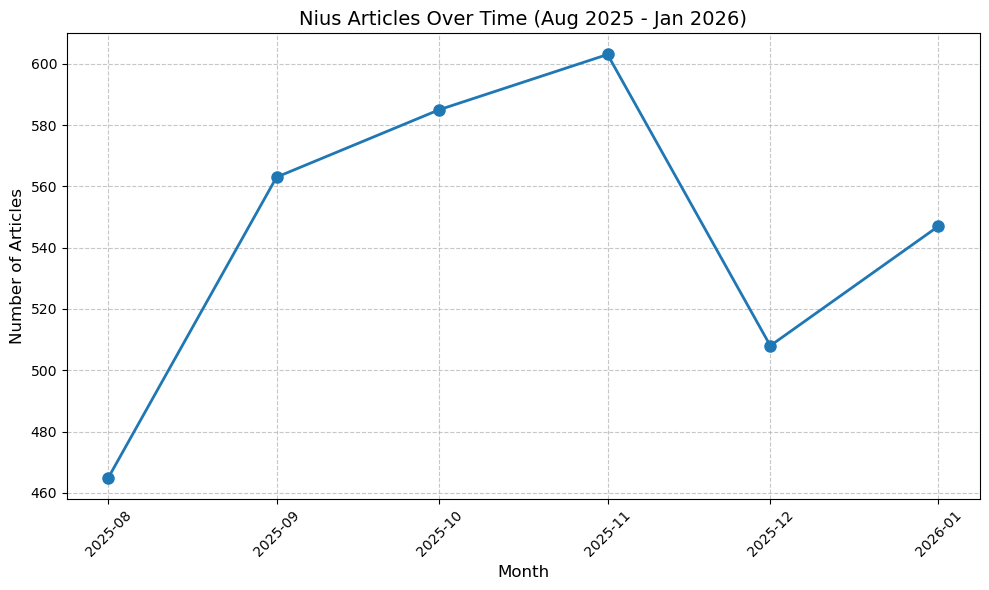

In [73]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Nius Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [80]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy()
eda_df["day"] = pd.to_datetime(eda_df["day"], errors="coerce")

eda_df["article_text"] = eda_df["article_text"].astype("string")
eda_df = eda_df.dropna(subset=["day", "article_text"]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 3,271


In [81]:
eda_df["article_length_words"] = eda_df["article_text"].str.split().str.len()
eda_df["article_length_chars"] = eda_df["article_text"].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    3271.0
mean      560.7
std       507.9
min         4.0
10%       139.0
25%       241.0
50%       418.0
75%       680.0
90%      1168.0
95%      1596.0
99%      2439.0
max      5932.0
Name: article_length_words, dtype: float64

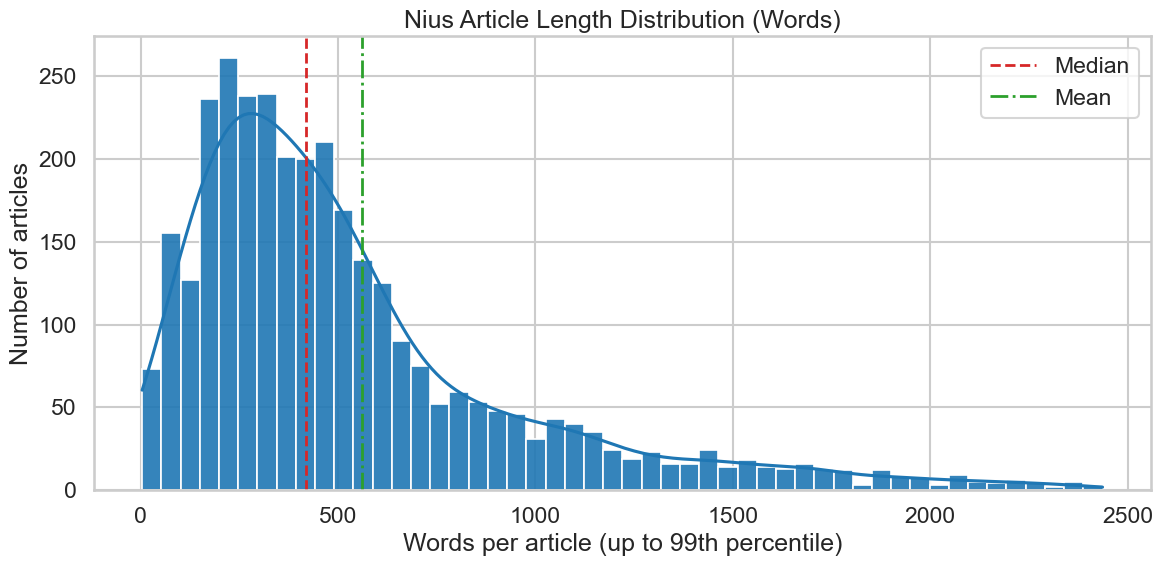

In [83]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Nius Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()